<a href="https://colab.research.google.com/github/LampOfSocrates/reid/blob/main/EEEM071_CourseWork_3103.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# This insures that 2 seconda after editing a module it gets reloaded without restarting the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Step 1: GPU Selection
1. Find "Edit" tab above, select "Hardware accelerator" and choose "GPU"
2. Run bellow command to check what GPU you got

In [1]:
from datetime import datetime

NOTEBOOK_START_TIME = datetime.now()

In [2]:
!nvidia-smi

Sun Apr 26 13:29:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   42C    P8             26W /  300W |    6338MiB /  16303MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Step 2: Code Preparation

We need to maintain our codebase with git history, so a file system (Google Drive) is needed
1. Select the left file icon and mount your Google Drive
2. Move path to Google Drive
3. Git clone code base


In [3]:
%%time

from pathlib import Path
import sys
import os

def is_colab() -> bool:
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if is_colab():
  from google.colab import drive
  drive.mount('/content/drive')

  %cd /content
  #!pip install -U --no-cache-dir gdown --pre
  !pip install -r requirements.txt

  # please download datasets from assignment doc link and upload, then unzip it.

  # Copy the uploaded zip from Google Drive into the Colab runtime, then unzip it locally.
  if not os.path.exists('/content/VeRi'):
      print('Unzipping VeRi dataset...')
      !cp "/content/drive/MyDrive/Colab Notebooks/data/VeRi.zip" /content/VeRi.zip
      !unzip /content/VeRi.zip -d /content/
  else:
      print('VeRi dataset already exists. Skipping unzip.')
  !ls -l /content

  # code
  if not os.path.exists('/content/reid'):
      print('Cloning repository...')
      !git clone https://github.com/LampOfSocrates/reid /content/reid
  else:
      print('Repository already exists. Pulling latest changes...')
      %cd /content/reid
      !git pull

  repo_root = Path('/content/reid')
  data_root = Path('/content/VeRi')

else: # Local run 
    repo_root = Path.cwd()
    data_root = Path(r'C:\Users\soura\Code\2026\reid\data')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f'is_colab={is_colab()}')
print(f'repo_root={repo_root}')
print(f'data_root={data_root}')

is_colab=False
repo_root=C:\Users\soura\code\2026\reid
data_root=C:\Users\soura\Code\2026\reid\data
CPU times: total: 0 ns
Wall time: 1.09 ms


In [16]:
if is_colab():
    %pip install timm
    %pip install pandas

# Step 3: Data Preparation

Because reading images from Google Drive is very slow, we download datasets to Colab temporary file
1. Install gdown
2. Download data
3. Unzip data with password

 Note that we have a folder called /content/drive/MyDrive/Veri with the full data

# Metrics Code

In [19]:
from coursework.src.utils.metrics_report import render_run, compare_runs, export_html


# Set Globals

6 model runs take 30 minutes with DATA_FRACTION at 1% and MAX_EPOCH at 10 . vgg16 doesnt even respond to that.

Let this be the checked in combination


In [6]:
from datetime import datetime

if is_colab(): 8 / 20 run 
    MAX_EPOCH = 16
    DATA_FRACTION = 0.5
else: # 1.2 / 20 run => 400 secs per model / 6 models = 2400 secs
    MAX_EPOCH = 12
    DATA_FRACTION = 0.1
RUNTIME = datetime.now().strftime("%d%m_%H%M")


# Step 4: Training New Models to choose 1 

## Run swin_t_custom

Student ID:<your id>
Student name:<your name>
UUID:8a8a4db4-68ff-420d-8bd0-4331a00ff8f2
Experiment time:2026-04-26 13:29:28
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=8, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='swin_t_custom', experiment='swin_t_custom', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', 

### swin_t_custom  —  best Rank-1: 67.07% · best mAP: 50.11% · 265s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,26.6738,5.9580,0.1458,3.1738,0.3110,0.5183,0.6280,0.7256,0.2330
1,2,24.3808,4.8193,0.0772,10.3271,0.4024,0.6220,0.7195,0.8293,0.2900
2,3,24.2222,3.8126,0.0650,23.3887,0.4817,0.7439,0.8049,0.8659,0.3713
3,4,24.3956,2.8858,0.0555,43.0420,0.5854,0.7927,0.8598,0.9146,0.4189
4,5,24.2806,2.0850,0.0402,61.9385,0.5793,0.8293,0.8780,0.9268,0.4449
5,6,24.3536,1.4208,0.0293,76.3428,0.6402,0.8537,0.9207,0.9573,0.4877
6,7,24.2499,0.9882,0.0365,85.1562,0.6707,0.8598,0.9207,0.9695,0.4845
7,8,24.3953,0.6896,0.0294,90.0879,0.6585,0.8902,0.9268,0.9573,0.5011


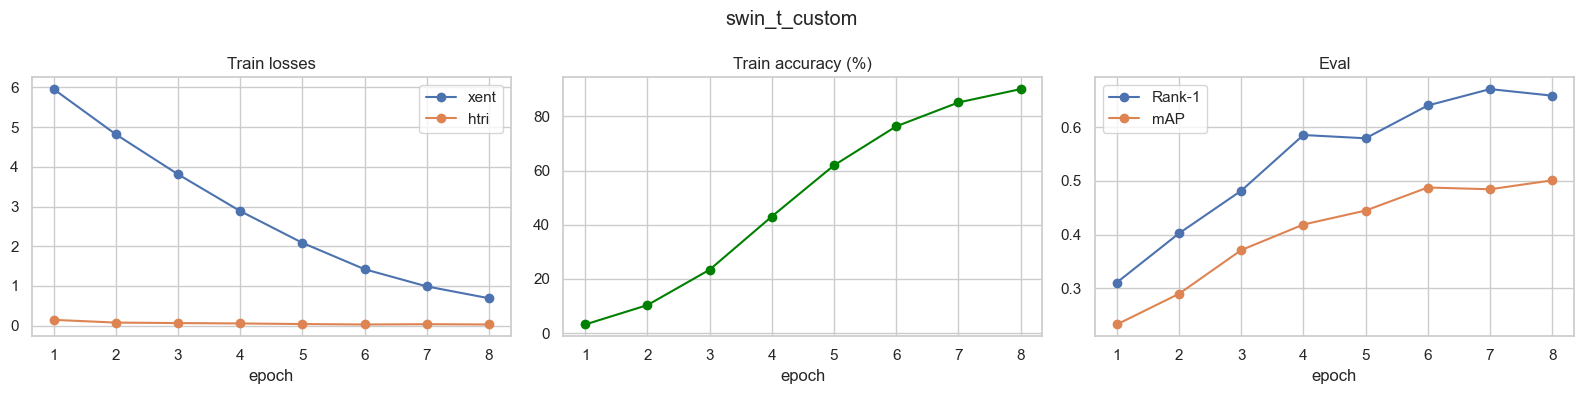

In [7]:

#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a swin_t_custom \
--experiment swin_t_custom \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/swin_t_custom-veri

render_run(f"logs/{RUNTIME}/Q1/swin_t_custom-veri")


## Run swin_t_fc512

Student ID:<your id>
Student name:<your name>
UUID:2d9ef5d2-01b4-4725-9394-36e908c572ed
Experiment time:2026-04-26 13:33:57
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=8, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='swin_t_fc512', experiment='swin_t_fc512', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume='', sa

### swin_t_fc512  —  best Rank-1: 62.80% · best mAP: 46.47% · 264s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,26.2803,6.0444,0.1761,2.5146,0.2744,0.4634,0.5427,0.6707,0.1848
1,2,24.5048,5.1448,0.0860,5.7861,0.4146,0.5732,0.6341,0.7317,0.2681
2,3,24.2048,4.4577,0.0827,11.9385,0.4573,0.6585,0.7073,0.7744,0.3229
3,4,24.3424,3.8035,0.0814,22.5342,0.5122,0.7134,0.7988,0.8537,0.3600
4,5,24.2370,3.1722,0.0625,35.0342,0.5427,0.7744,0.8293,0.8902,0.4048
5,6,24.4020,2.5618,0.0588,50.0977,0.6159,0.7561,0.8659,0.9390,0.4443
6,7,24.3318,1.9956,0.0462,63.7695,0.6280,0.8476,0.8902,0.9207,0.4633
7,8,24.3626,1.5667,0.0426,73.8770,0.6098,0.8537,0.8963,0.9451,0.4647


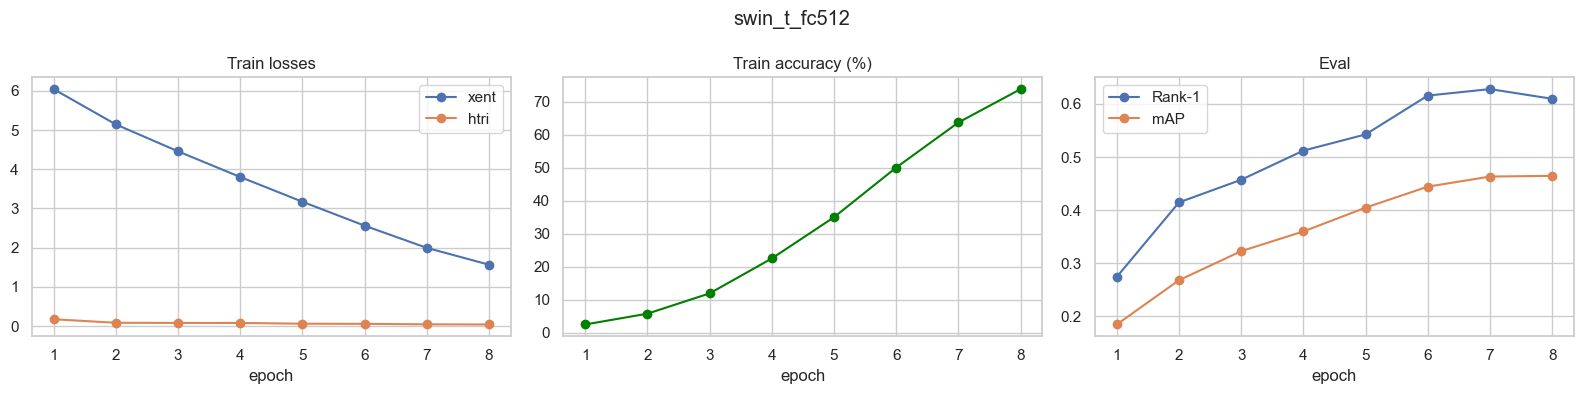

In [8]:

#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a swin_t_fc512 \
--experiment swin_t_fc512 \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/swin_t_fc512-veri

render_run(f"logs/{RUNTIME}/Q1/swin_t_fc512-veri")


## Run clip_senet_v1_dual

Student ID:<your id>
Student name:<your name>
UUID:adbda030-e9e2-44fd-a9c0-90c976d5b985
Experiment time:2026-04-26 14:41:45
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.00035, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=8, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='clip_senet_v1_dual', experiment='clip_senet_v1_dual', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, 

C:\Users\soura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\soura\.cache\huggingface\hub\models--timm--resnet50.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\soura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\fil

### clip_senet_v1_dual  —  best Rank-1: 50.61% · best mAP: 35.55% · 317s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,39.5760,6.1504,0.3396,3.7842,0.1890,0.3963,0.4634,0.5244,0.1223
1,2,25.4407,5.2623,0.1125,8.9111,0.2256,0.4451,0.5366,0.6646,0.1657
2,3,25.7968,4.5004,0.0953,16.8945,0.2866,0.5061,0.6159,0.7500,0.2118
3,4,25.4006,3.7605,0.0644,29.2969,0.3110,0.5549,0.7317,0.8171,0.2472
4,5,25.1219,3.0009,0.0628,47.6318,0.4024,0.6585,0.7378,0.8415,0.2946
5,6,25.1528,2.2238,0.0424,67.0410,0.4695,0.6951,0.7988,0.8780,0.3240
6,7,25.1525,1.5382,0.0328,81.3477,0.4756,0.7073,0.8110,0.8780,0.3371
7,8,25.3905,0.9944,0.0209,90.1855,0.5061,0.7561,0.8171,0.8720,0.3555


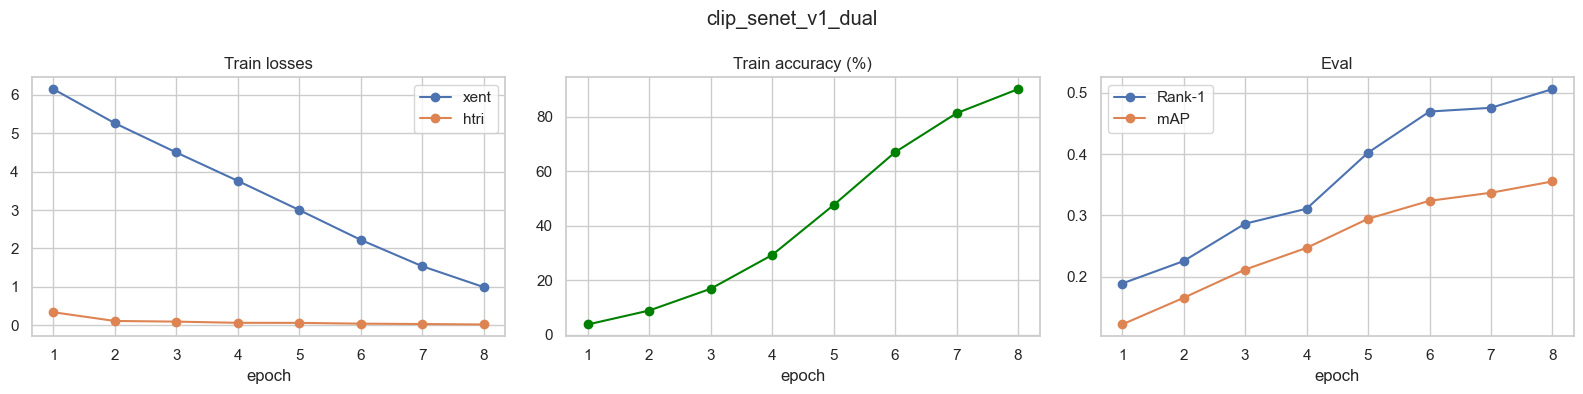

In [14]:
#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a clip_senet_v1_dual \
--experiment clip_senet_v1_dual \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 3.5e-4 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/clip_senet_v1_dual-veri

render_run(f"logs/{RUNTIME}/Q1/clip_senet_v1_dual-veri")


## Run clip_senet_v2_frozen

In [13]:
'''
#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a clip_senet_v2_frozen \
--experiment clip_senet_v2_frozen \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/clip_senet_v2_frozen-veri

render_run(f"logs/{RUNTIME}/Q1/clip_senet_v2_frozen-veri")
'''

'\n#!STUDENT_ID=\'ss05548\' STUDENT_NAME="Sourav Sen" \n!python coursework/main.py -s veri -t veri -a clip_senet_v2_frozen --experiment clip_senet_v2_frozen --root "C:\\Users\\soura\\Code\\2026\\reid\\data" --height 224 --width 224 --optim amsgrad --lr 0.0003 --max-epoch {MAX_EPOCH} --stepsize 20 40 --eval-freq 1 --train-batch-size 64 --test-batch-size 100 --data-fraction {DATA_FRACTION} --train-sampler \'RandomIdentitySampler\' --save-dir logs/{RUNTIME}/Q1/clip_senet_v2_frozen-veri\n\nrender_run(f"logs/{RUNTIME}/Q1/clip_senet_v2_frozen-veri")\n'

# Section 1: Familiarity with the code provided (30 marks)

1. Run the code using the default settings. Discuss the training and evaluation
process (mention the loss functions used) followed by implications of the observed
performance using an appropriate metric. (10 marks)
2. Apply another CNN variant (that is not provided in the default settings). Critically
discuss and contrast the results with what observed in question 1 above. (10
marks)
3. Apply one more neural network architecture not from the same family as the above
questions. Critically discuss and contrast the results with what observed questions
1 and 2 above. (10 marks)

## Run default settings mobilenet_v3_small

Student ID:<your id>
Student name:<your name>
UUID:c6904003-d936-4947-888e-325e7c0e3af7
Experiment time:2026-04-26 14:47:37
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=8, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='mobilenet_v3_small', experiment='mobilenet_v3_small', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, r

C:\Users\soura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\soura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### mobilenet_v3_small  —  best Rank-1: 37.80% · best mAP: 28.21% · 246s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,29.7245,6.3047,0.1632,0.9277,0.2683,0.4756,0.5549,0.6768,0.1695
1,2,16.6813,5.6685,0.1363,3.8086,0.3171,0.5122,0.5671,0.6890,0.2011
2,3,16.3541,5.0227,0.1492,7.6660,0.2866,0.4878,0.5915,0.6829,0.2001
3,4,16.1547,4.4677,0.1617,14.6729,0.3049,0.5427,0.6159,0.7439,0.2262
4,5,16.2352,3.9769,0.1756,22.6318,0.3537,0.5671,0.6890,0.7805,0.2552
5,6,16.1180,3.5147,0.1795,30.1758,0.3720,0.5549,0.6524,0.8049,0.2686
6,7,16.0141,3.0833,0.1278,40.7959,0.3720,0.5793,0.7012,0.8232,0.2703
7,8,16.3957,2.6863,0.1661,48.9746,0.3780,0.6220,0.7134,0.8293,0.2821


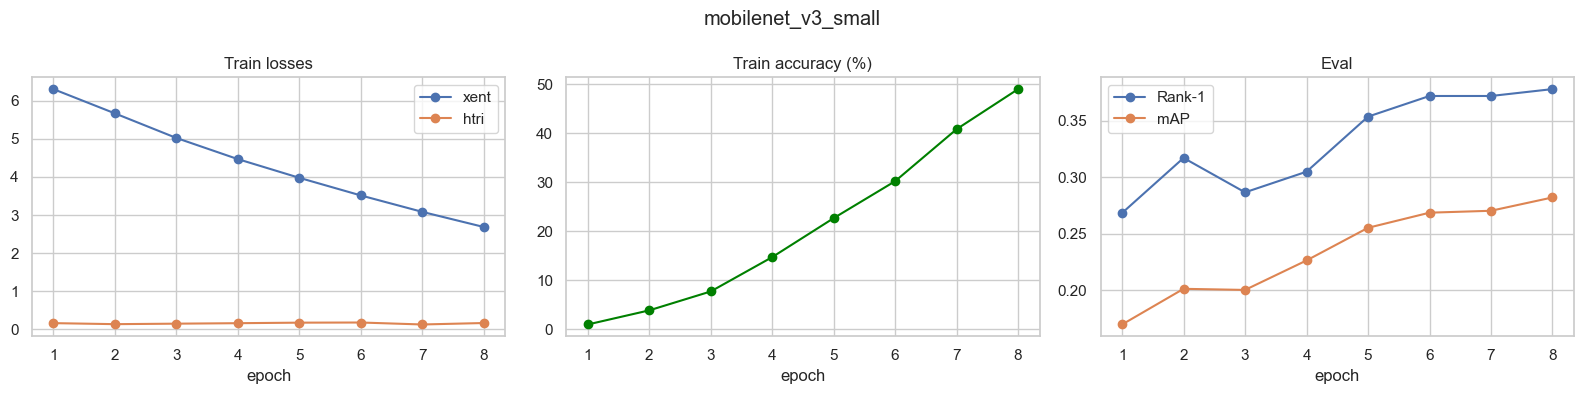

In [15]:


#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a mobilenet_v3_small \
--experiment mobilenet_v3_small \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/mobilenet_v3_small-veri

render_run(f"logs/{RUNTIME}/Q1/mobilenet_v3_small-veri")

## Run resnet50_fc512

Student ID:<your id>
Student name:<your name>
UUID:b9d10f81-64e3-4c1c-a77b-a8ac4b90e401
Experiment time:2026-04-26 14:57:08
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=0.1, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=8, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512', no_pretrained=False, load_weights='', evaluate=False, eval_freq=1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, resume=''

### resnet50_fc512  —  best Rank-1: 31.10% · best mAP: 24.09% · 306s

,epoch,epoch_time_seconds,avg_xent,avg_htri,avg_acc,rank1,rank5,rank10,rank20,mAP
0,1,38.6271,6.0808,0.4156,2.0996,0.1220,0.2866,0.4085,0.5000,0.0973
1,2,24.5791,5.3997,0.3452,3.3203,0.1951,0.3659,0.4756,0.5854,0.1347
2,3,24.3843,5.0361,0.2952,4.3213,0.1890,0.3598,0.4634,0.5915,0.1419
3,4,24.2305,4.7796,0.2749,5.8838,0.1951,0.4146,0.5305,0.6280,0.1702
4,5,24.1631,4.5303,0.2969,7.9346,0.2439,0.4329,0.5488,0.6646,0.1853
5,6,24.2195,4.2637,0.2580,10.6934,0.2195,0.4390,0.5732,0.6524,0.1959
6,7,24.0242,4.0012,0.2322,14.5996,0.3110,0.4878,0.5854,0.7073,0.2336
7,8,23.8366,3.7733,0.2067,17.1631,0.2805,0.5183,0.6098,0.7744,0.2409


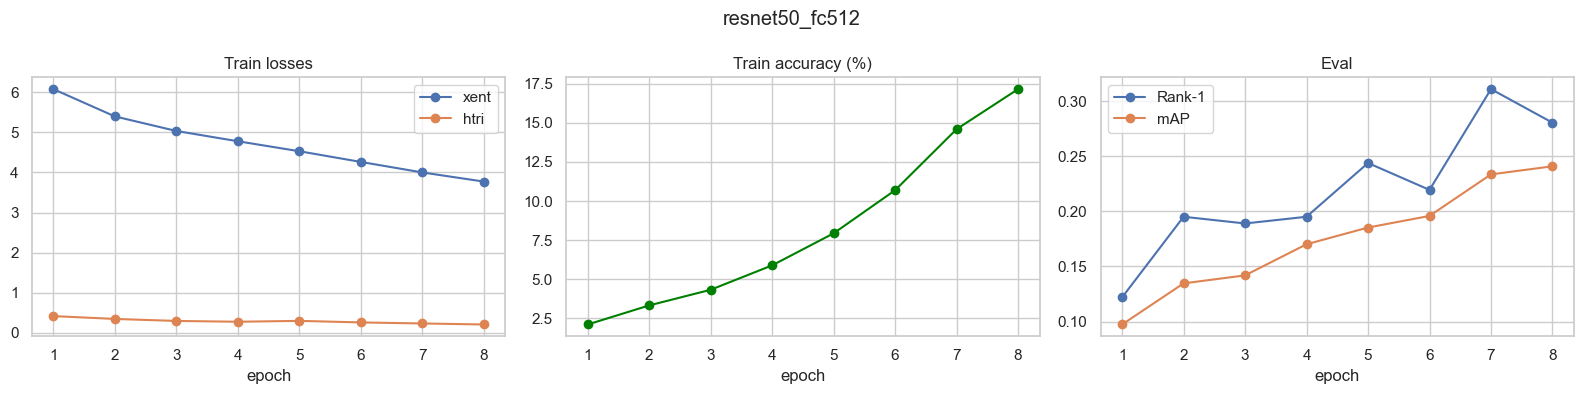

In [17]:

#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a resnet50_fc512 \
--experiment resnet50_fc512 \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--save-dir logs/{RUNTIME}/Q1/resnet50_fc512-veri

render_run(f"logs/{RUNTIME}/Q1/resnet50_fc512-veri")

# Compare Section 1 Runs

### Summary

,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,swin_t_custom,67.07%,50.11%,65.85%,50.11%,24.6,265
1,swin_t_fc512,62.80%,46.47%,60.98%,46.47%,24.6,264
2,clip_senet_v1_dual,50.61%,35.55%,50.61%,35.55%,27.1,317
4,mobilenet_v3_small,37.80%,28.21%,37.80%,28.21%,18.0,246
3,resnet50_fc512,31.10%,24.09%,28.05%,24.09%,26.0,306


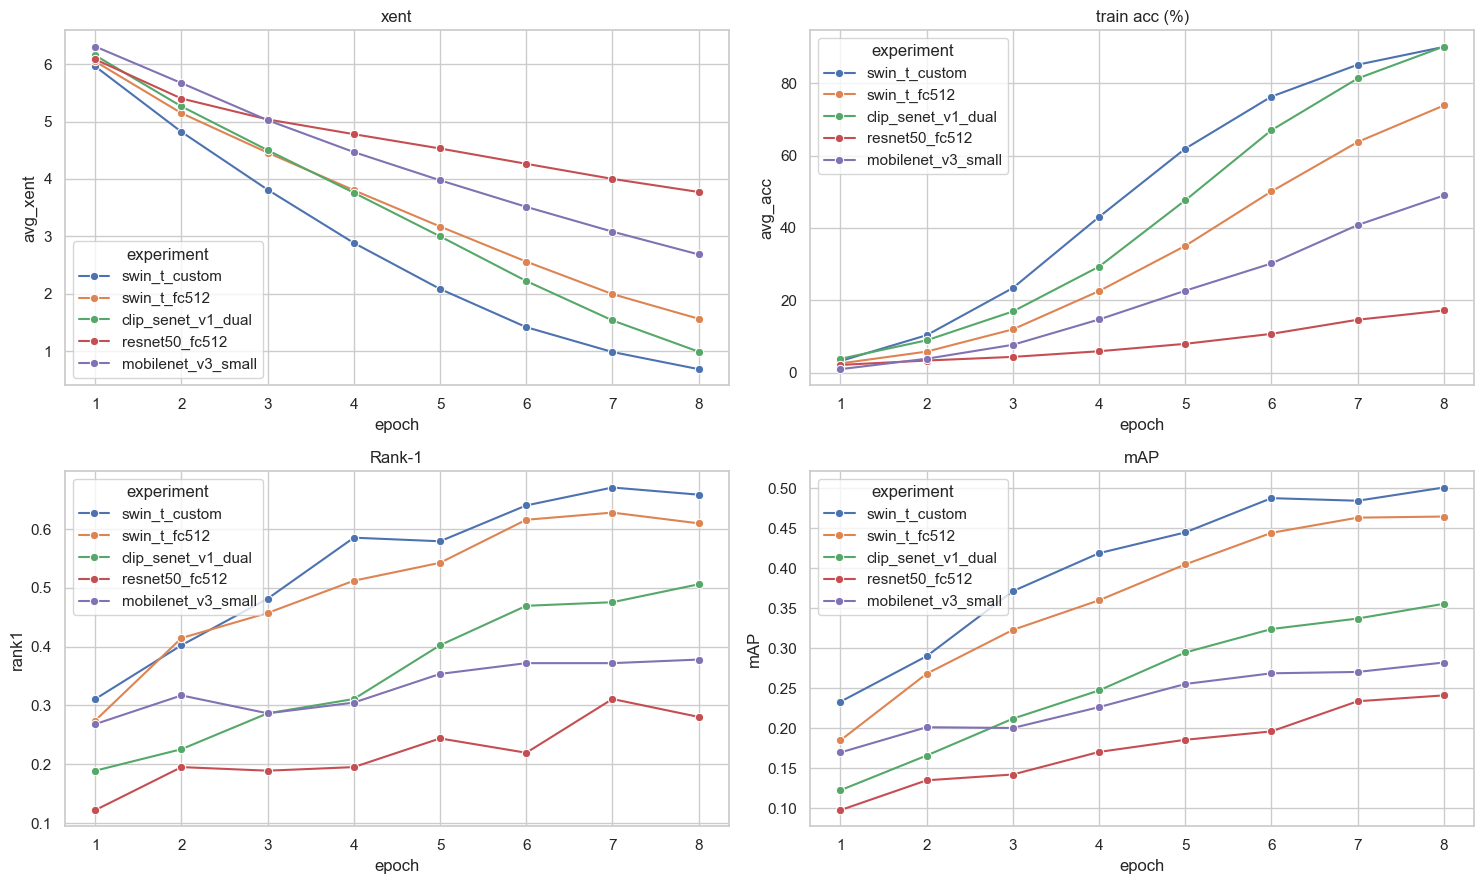

Wrote C:\Users\soura\Code\2026\reid\coursework\reports\comparison_2604_1329.html


,experiment,best_rank1,best_mAP,final_rank1,final_mAP,avg_epoch_s,total_s
0,swin_t_custom,0.670732,0.501061,0.658537,0.501061,24.618967,264.915884
1,swin_t_fc512,0.628049,0.464726,0.609756,0.464726,24.583221,264.448932
2,clip_senet_v1_dual,0.506098,0.355531,0.506098,0.355531,27.128983,317.043964
4,mobilenet_v3_small,0.378049,0.282067,0.378049,0.282067,17.959713,245.762675
3,resnet50_fc512,0.310976,0.240909,0.280488,0.240909,26.008038,305.905825


In [27]:
compare_runs([
    f"logs/{RUNTIME}/Q1/swin_t_custom-veri",
    f"logs/{RUNTIME}/Q1/swin_t_fc512-veri",
    #f"logs/{RUNTIME}/Q1/clip_senet_v2_frozen-veri",
    f"logs/{RUNTIME}/Q1/clip_senet_v1_dual-veri",
    f"logs/{RUNTIME}/Q1/resnet50_fc512-veri",
    f"logs/{RUNTIME}/Q1/mobilenet_v3_small-veri", 
    ], 
    runtime=RUNTIME,
    html=True,)



### Basic Table Section 1

In [20]:
from pathlib import Path
import json
import pandas as pd


def get_logs(runtime, question):
    if question not in {"Q1", "Q2"}:
        raise ValueError("question must be 'Q1' or 'Q2'")

    runs_root = Path("logs") / runtime / question
    rows = []

    for path in runs_root.rglob("comparison_summary.json"):
        print(path)
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        rows.append({
            "arch": data.get("arch"),
            "experiment": data.get("experiment") or data.get("arch"),
            "run_dir": data.get("run_save_dir"),
            "timestamp": data.get("timestamp"),
            "lr": data.get("lr"),
            "train_batch_size": data.get("train_batch_size"),
            "test_batch_size": data.get("test_batch_size"),
            "data_fraction": data.get("data_fraction"),
            "best_rank1": data.get("best_rank1"),
            "best_mAP": data.get("best_mAP"),
            "final_rank1": (data.get("final_eval") or {}).get("rank1"),
            "final_mAP": (data.get("final_eval") or {}).get("mAP"),
            "total_elapsed_seconds": data.get("total_elapsed_seconds"),
            "avg_epoch_time_seconds": data.get("avg_epoch_time_seconds"),
        })

    return pd.DataFrame(rows)


df_q1 = get_logs(RUNTIME, "Q1")
display(df_q1)


logs\2604_1329\Q1\clip_senet_v1_dual-veri_20260426_144145\comparison_summary.json
logs\2604_1329\Q1\clip_senet_v2_frozen-veri_20260426_133826\comparison_summary.json
logs\2604_1329\Q1\mobilenet_v3_small-veri_20260426_144737\comparison_summary.json
logs\2604_1329\Q1\resnet50_fc512-veri_20260426_145708\comparison_summary.json
logs\2604_1329\Q1\swin_t_custom-veri_20260426_132928\comparison_summary.json
logs\2604_1329\Q1\swin_t_fc512-veri_20260426_133357\comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
0,clip_senet_v1_dual,clip_senet_v1_dual,logs/2604_1329/Q1/clip_senet_v1_dual-veri_2026...,20260426_144145,0.00035,64,100,0.1,0.506098,0.355531,0.506098,0.355531,317.043964,27.128983
1,clip_senet_v2_frozen,clip_senet_v2_frozen,logs/2604_1329/Q1/clip_senet_v2_frozen-veri_20...,20260426_133826,0.00030,64,100,0.1,0.298781,0.201674,0.298781,0.201674,197.970850,16.762645
2,mobilenet_v3_small,mobilenet_v3_small,logs/2604_1329/Q1/mobilenet_v3_small-veri_2026...,20260426_144737,0.00030,64,100,0.1,0.378049,0.282067,0.378049,0.282067,245.762675,17.959713
3,resnet50_fc512,resnet50_fc512,logs/2604_1329/Q1/resnet50_fc512-veri_20260426...,20260426_145708,0.00030,64,100,0.1,0.310976,0.240909,0.280488,0.240909,305.905825,26.008038
4,swin_t_custom,swin_t_custom,logs/2604_1329/Q1/swin_t_custom-veri_20260426_...,20260426_132928,0.00030,64,100,0.1,0.670732,0.501061,0.658537,0.501061,264.915884,24.618967
5,swin_t_fc512,swin_t_fc512,logs/2604_1329/Q1/swin_t_fc512-veri_20260426_1...,20260426_133357,0.00030,64,100,0.1,0.628049,0.464726,0.609756,0.464726,264.448932,24.583221


C:\Users\soura\AppData\Local\Temp\ipykernel_16832\2668935844.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
C:\Users\soura\AppData\Local\Temp\ipykernel_16832\2668935844.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='experiment', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')


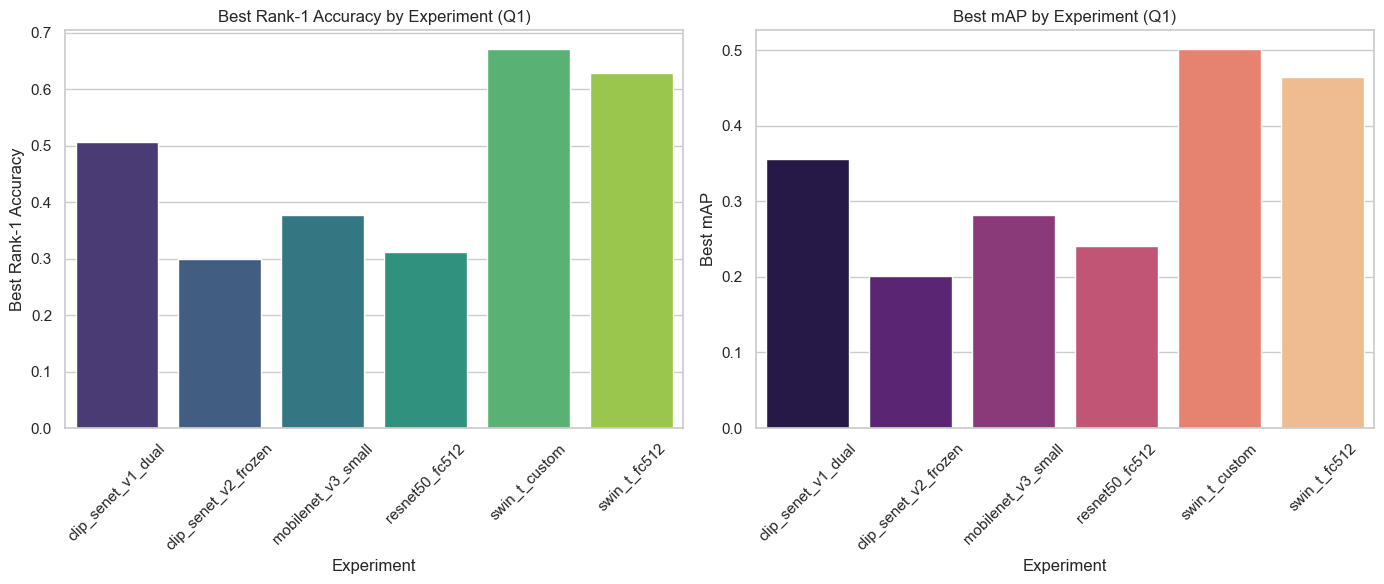

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for best_rank1
sns.barplot(x='experiment', y='best_rank1', data=df_q1, ax=axes[0], palette='viridis')
axes[0].set_title('Best Rank-1 Accuracy by Experiment (Q1)')
axes[0].set_xlabel('Experiment')
axes[0].set_ylabel('Best Rank-1 Accuracy')
axes[0].tick_params(axis='x', rotation=45)

# Plot for best_mAP
sns.barplot(x='experiment', y='best_mAP', data=df_q1, ax=axes[1], palette='magma')
axes[1].set_title('Best mAP by Experiment (Q1)')
axes[1].set_xlabel('Experiment')
axes[1].set_ylabel('Best mAP')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [22]:
print('Performance Comparison:')
print('-----------------------')

resnet_perf = df_q1[df_q1['experiment'] == 'resnet50_fc512'][['experiment', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]
clip_perf = df_q1[df_q1['experiment'] == 'clip_senet'][['experiment', 'best_rank1', 'best_mAP', 'total_elapsed_seconds']].iloc[0]

print(f"Experiment: {resnet_perf['experiment']}")
print(f"  Best Rank-1: {resnet_perf['best_rank1']:.2f}")
print(f"  Best mAP: {resnet_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {resnet_perf['total_elapsed_seconds']:.2f} seconds\n")

print(f"Experiment: {clip_perf['experiment']}")
print(f"  Best Rank-1: {clip_perf['best_rank1']:.2f}")
print(f"  Best mAP: {clip_perf['best_mAP']:.2f}")
print(f"  Total Elapsed Time: {clip_perf['total_elapsed_seconds']:.2f} seconds")

print('\nAnalysis:')
if resnet_perf['best_rank1'] > clip_perf['best_rank1']:
    print(f"- resnet50_fc512 has a higher Rank-1 accuracy ({resnet_perf['best_rank1']:.2f}) than clip_senet ({clip_perf['best_rank1']:.2f}).")
else:
    print(f"- clip_senet has a higher Rank-1 accuracy ({clip_perf['best_rank1']:.2f}) than resnet50_fc512 ({resnet_perf['best_rank1']:.2f}).")

if resnet_perf['best_mAP'] > clip_perf['best_mAP']:
    print(f"- resnet50_fc512 has a higher mAP ({resnet_perf['best_mAP']:.2f}) than clip_senet ({clip_perf['best_mAP']:.2f}).")
else:
    print(f"- clip_senet has a higher mAP ({clip_perf['best_mAP']:.2f}) than resnet50_fc512 ({resnet_perf['best_mAP']:.2f}).")

if resnet_perf['total_elapsed_seconds'] < clip_perf['total_elapsed_seconds']:
    print(f"- resnet50_fc512 trained faster ({resnet_perf['total_elapsed_seconds']:.2f}s) than clip_senet ({clip_perf['total_elapsed_seconds']:.2f}s).")
else:
    print(f"- clip_senet trained faster ({clip_perf['total_elapsed_seconds']:.2f}s) than resnet50_fc512 ({resnet_perf['total_elapsed_seconds']:.2f}s).")


Performance Comparison:
-----------------------


IndexError: single positional indexer is out-of-bounds

### Parse Logs for Epoch stats

In [ ]:
import json
import re
import pandas as pd
from pathlib import Path

def parse_epoch_logs(log_text, experiment_name):
    epochs_data = []
    pattern = r"Epoch\s+(\d+)/\d+.*?acc=([\d.]+).*?htri=([\d.]+).*?xent=([\d.]+)"

    for line in log_text.splitlines():
        match = re.search(pattern, line)
        if match:
            epochs_data.append({
                'experiment': experiment_name,
                'epoch': int(match.group(1)),
                'acc': float(match.group(2)),
                'htri': float(match.group(3)),
                'xent': float(match.group(4))
            })
    return epochs_data

def get_all_epoch_data(runtime_dir='3103_2306', question='Q1'):
    all_data = []
    log_root = Path('logs') / runtime_dir / question
    print(f"Parsing logs from {log_root}")

    for summary_path in log_root.rglob('comparison_summary.json'):
        print(summary_path)
        with open(summary_path, 'r', encoding='utf-8') as f:
            summary = json.load(f)

        experiment = summary.get('experiment') or summary.get('arch')
        log_path = Path(summary.get('run_save_dir', summary_path.parent)) / 'log_train.txt'
        if not log_path.exists():
            log_path = summary_path.parent / 'log_train.txt'
        if not log_path.exists():
            continue

        with open(log_path, 'r', encoding='utf-8') as f:
            all_data.extend(parse_epoch_logs(f.read(), experiment))

    return pd.DataFrame(all_data)


all_epochs_df = get_all_epoch_data(RUNTIME)
display(all_epochs_df)


### Per Epoch Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=False)
fig.suptitle('Training Metrics Comparison (Q1)', fontsize=16)

# Accuracy
sns.lineplot(data=all_epochs_df, x='epoch', y='acc', hue='experiment', marker='o', ax=axes[0])
axes[0].set_title('Accuracy per Epoch')

# Triplet Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='htri', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('Triplet Loss (htri) per Epoch')

# Cross-Entropy Loss
sns.lineplot(data=all_epochs_df, x='epoch', y='xent', hue='experiment', marker='o', ax=axes[2])
axes[2].set_title('Cross-Entropy Loss (xent) per Epoch')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate the percentage reduction in loss and increase in accuracy from Epoch 1 to Final Epoch
analysis = []
for experiment in all_epochs_df['experiment'].unique():
    subset = all_epochs_df[all_epochs_df['experiment'] == experiment].sort_values('epoch')
    first = subset.iloc[0]
    last = subset.iloc[-1]

    loss_reduction = ((first['xent'] - last['xent']) / first['xent']) * 100
    acc_improvement = last['acc'] - first['acc']

    analysis.append({
        'Experiment': experiment,
        'Loss Reduction (%)': loss_reduction,
        'Absolute Acc Gain': acc_improvement
    })

df_analysis = pd.DataFrame(analysis)
print("Comparison of Learning Efficiency:")
display(df_analysis)

# Plotting the disconnect
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

df_analysis.plot(x='Experiment', y='Loss Reduction (%)', kind='bar', ax=ax1, position=1, width=0.4, color='skyblue', label='Loss Reduc %')
df_analysis.plot(x='Experiment', y='Absolute Acc Gain', kind='bar', ax=ax2, position=0, width=0.4, color='orange', label='Acc Gain')

ax1.set_ylabel('Loss Reduction %')
ax2.set_ylabel('Accuracy Gain')
plt.title('Loss Reduction vs. Accuracy Gain per Experiment')
plt.show()


# Section 2: Dataset preparation and augmentation experiment (25 marks)

Begin with the default data augmentation setting with random, horizontal flip and
Random2DTranslation.
1. Further append on top two additional data augmentation techniques, one at a time
e.g., Default + “crop”, Default + “horizontal flip”, and Default + “blurring”. Compare
the results with the default configuration in the provided code and discuss the
differences in performance. (20 marks)
2. Combine the augmentation techniques from Question 1 to find the best-performing
combination. Highlight any improvement or drop in the overall score. (5 marks)

## Run Crop Resnet50_fc512

In [44]:
MAX_EPOCH=20
#!STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a resnet50_fc512 \
--experiment resnet50_fc512_crop \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--crop-aug \
--save-dir logs/{RUNTIME}/Q2/resnet50_fc512_crop


Student ID:<your id>
Student name:<your name>
UUID:db405bd1-ee1c-412b-9712-7dbbbf089275
Experiment time:2026-04-22 15:21:27
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=1.0, random_erase=False, color_jitter=False, color_aug=False, crop_aug=True, blur_aug=False, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=20, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_crop', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, res

## Run Blur Resnet50_fc512

In [45]:

MAX_EPOCH=20
#STUDENT_ID='ss05548' STUDENT_NAME="Sourav Sen" 
!python coursework/main.py \
-s veri \
-t veri \
-a resnet50_fc512 \
--experiment resnet50_fc512_blur \
--root "C:\\Users\\soura\\Code\\2026\\reid\\data" \
--height 224 \
--width 224 \
--optim amsgrad \
--lr 0.0003 \
--max-epoch {MAX_EPOCH} \
--stepsize 20 40 \
--eval-freq 1 \
--train-batch-size 64 \
--test-batch-size 100 \
--data-fraction {DATA_FRACTION} \
--train-sampler 'RandomIdentitySampler' \
--blur-aug \
--save-dir logs/{RUNTIME}/Q2/resnet50_fc512_blur


Student ID:<your id>
Student name:<your name>
UUID:3ee47054-b88c-4b76-884d-b77633fc0a23
Experiment time:2026-04-22 16:10:42
Args:Namespace(root='C:\\\\Users\\\\soura\\\\Code\\\\2026\\\\reid\\\\data', source_names=['veri'], target_names=['veri'], workers=4, split_id=0, height=224, width=224, train_sampler="'RandomIdentitySampler'", data_fraction=1.0, random_erase=False, color_jitter=False, color_aug=False, crop_aug=False, blur_aug=True, optim='amsgrad', lr=0.0003, weight_decay=0.0005, momentum=0.9, sgd_dampening=0, sgd_nesterov=False, rmsprop_alpha=0.99, adam_beta1=0.9, adam_beta2=0.999, max_epoch=20, start_epoch=0, train_batch_size=64, test_batch_size=100, lr_scheduler='multi_step', stepsize=[20, 40], gamma=0.1, label_smooth=False, margin=0.3, num_instances=4, lambda_xent=1, lambda_htri=1, arch='resnet50_fc512', experiment='resnet50_fc512_blur', no_pretrained=False, load_weights='', evaluate=False, eval_freq=-1, start_eval=0, test_size=800, query_remove=True, print_freq=10, seed=1, res

## Compare Section 2 Runs


### Basic Table Section 2

In [46]:
experiment_to_filter = 'resnet50_fc512'

df_q1_all = get_logs(RUNTIME, "Q1")
df_q1_filtered = df_q1_all[df_q1_all['experiment'] == experiment_to_filter]
display(df_q1_filtered)

df_q2 = get_logs(RUNTIME, "Q2")
df_comparison = pd.concat([df_q1_filtered, df_q2], ignore_index=True)
display(df_comparison)


logs\2204_0839\Q1\clip_senet-veri_20260422_105543\comparison_summary.json
logs\2204_0839\Q1\mobilenet_v3_small-veri_20260422_084012\comparison_summary.json
logs\2204_0839\Q1\resnet50_fc512-veri_20260422_090404\comparison_summary.json
logs\2204_0839\Q1\vgg16-veri_20260422_095402\comparison_summary.json
logs\2204_0839\Q1\vgg16-veri_20260422_121236\comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
2,resnet50_fc512,resnet50_fc512,logs/2204_0839/Q1/resnet50_fc512-veri_20260422...,20260422_090404,0.0003,64,100,1.0,0.891538,0.571005,0.891538,0.571005,2909.198472,141.388677


logs\2204_0839\Q2\resnet50_fc512_blur_20260422_161042\comparison_summary.json
logs\2204_0839\Q2\resnet50_fc512_crop_20260422_152127\comparison_summary.json


,arch,experiment,run_dir,timestamp,lr,train_batch_size,test_batch_size,data_fraction,best_rank1,best_mAP,final_rank1,final_mAP,total_elapsed_seconds,avg_epoch_time_seconds
0,resnet50_fc512,resnet50_fc512,logs/2204_0839/Q1/resnet50_fc512-veri_20260422...,20260422_090404,0.0003,64,100,1.0,0.891538,0.571005,0.891538,0.571005,2909.198472,141.388677
1,resnet50_fc512,resnet50_fc512_blur,logs/2204_0839/Q2/resnet50_fc512_blur_20260422...,20260422_161042,0.0003,64,100,1.0,0.882598,0.586019,0.882598,0.586019,2910.165288,141.327856
2,resnet50_fc512,resnet50_fc512_crop,logs/2204_0839/Q2/resnet50_fc512_crop_20260422...,20260422_152127,0.0003,64,100,1.0,0.912992,0.618347,0.912992,0.618347,2950.716721,143.474304


In [47]:
# Extract Q2 augmentation data
df_q2_epochs = get_all_epoch_data(RUNTIME, question='Q2')
df_q2_crop = df_q2_epochs[df_q2_epochs['experiment'] == 'resnet50_fc512_crop'].copy()
df_q2_blur = df_q2_epochs[df_q2_epochs['experiment'] == 'resnet50_fc512_blue'].copy()

# Get Q1 baseline for comparison
df_baseline = all_epochs_df[all_epochs_df['experiment'] == 'resnet50_fc512'].copy()

# Combine for plotting
df_aug_comp = pd.concat([df_baseline, df_q2_crop, df_q2_blur], ignore_index=True)
display(df_aug_comp)


Parsing logs from logs\2204_0839\Q2
logs\2204_0839\Q2\resnet50_fc512_blur_20260422_161042\comparison_summary.json
logs\2204_0839\Q2\resnet50_fc512_crop_20260422_152127\comparison_summary.json


,experiment,epoch,acc,htri,xent
0,resnet50_fc512,1,2.03,0.2927,6.3075
1,resnet50_fc512,1,2.03,0.2927,6.3075
2,resnet50_fc512,1,2.03,0.2927,6.3075
3,resnet50_fc512,1,2.03,0.2927,6.3075
4,resnet50_fc512,1,2.03,0.2927,6.3075
...,...,...,...,...,...
25635,resnet50_fc512_crop,20,99.53,0.0019,0.0519
25636,resnet50_fc512_crop,20,99.53,0.0019,0.0519
25637,resnet50_fc512_crop,20,99.53,0.0020,0.0518
25638,resnet50_fc512_crop,20,99.53,0.0020,0.0518


### Comparision Plots Section 2 : Augmentation Experiment


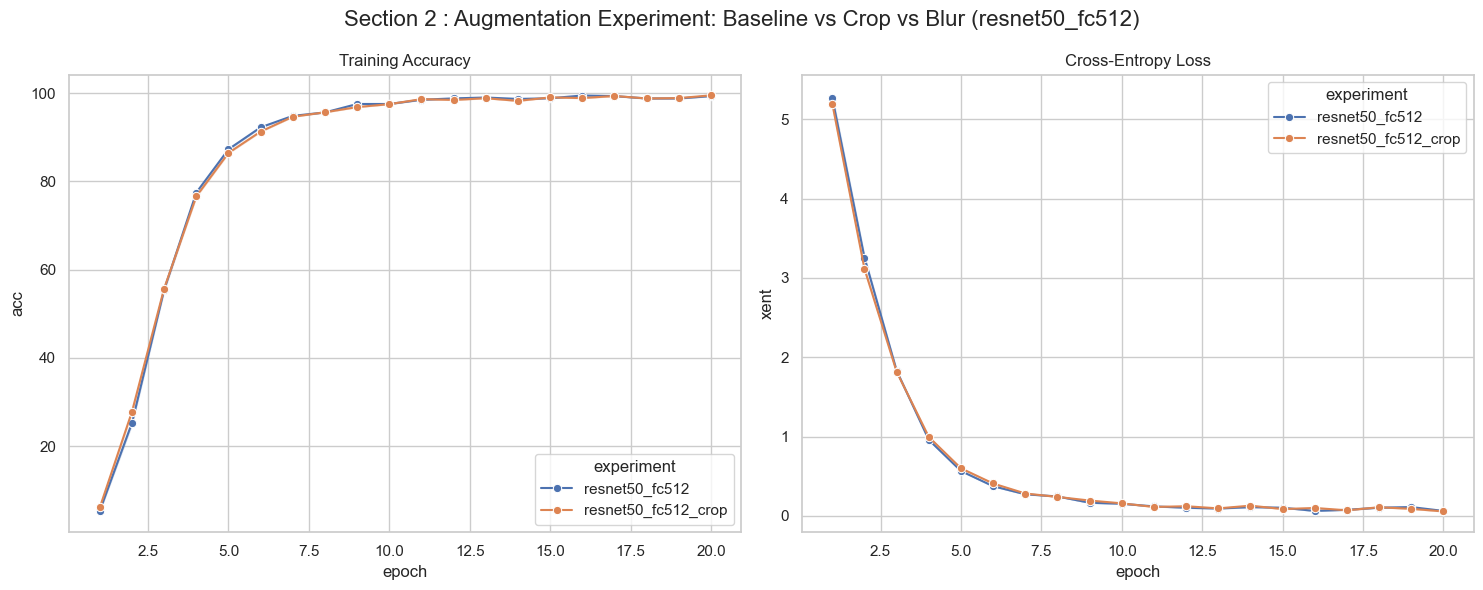

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Section 2 : Augmentation Experiment: Baseline vs Crop vs Blur (resnet50_fc512)', fontsize=16)

# Accuracy Comparison
sns.lineplot(data=df_aug_comp, x='epoch', y='acc', hue='experiment', marker='o', ax=axes[0])
axes[0].set_title('Training Accuracy')

# Loss Comparison (xent)
sns.lineplot(data=df_aug_comp, x='epoch', y='xent', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('Cross-Entropy Loss')

plt.tight_layout()
plt.show()


# Section 3: Exploration of Hyperparameters (25 marks)

Start with the default learning rate (LR) and batch size (BS).
1. Exploration of Learning Rate (LR). (10 marks)
a. Experiment with 4 values of LR (in addition to the default value).
b. Discuss the observed impact of each value on overall performance.
2. Exploration Batch sizes. (10 marks)
a. Fixing the best LR value from the experiments in question 1
above, test 4 different values of the BS in addition to the default
value.
b. Discuss the impact observed on overall performance.
3. Exploration of the optimizer. (5 marks)
3. Fixing the best Learning Rate value and best Batch Size value from the
experiments in Questions 1 and 2, respectively, test with changing the
optimizer to SGD, using PyTorch’s internal class.
a. Discuss the impact observed on overall performance

In [49]:
import os
STUDENT_ID = "ss05548"
STUDENT_NAME = "Sourav Sen"
RUNTIME = datetime.now().strftime("%Y%m%d_%H%M%S")

PROJECT_ROOT = Path.cwd()
COURSEWORK_DIR = PROJECT_ROOT / "coursework"
MAIN_PY = COURSEWORK_DIR / "main.py"

BASE_ARGS = {
    "source": "veri",
    "target": "veri",
    "arch": "clip_senet_v2_frozen",
    "root": "C:\\Users\\soura\\Code\\2026\\reid\\data",
    "height": 224,
    "width": 224,
    "optim": "amsgrad",
    "lr": 0.0003,
    "max_epoch": MAX_EPOCH,
    "stepsize": [20, 40],
    "eval-freq": 1 
    "train_batch_size": 64,
    "test_batch_size": 100,
    "data_fraction": DATA_FRACTION,
    "train_sampler": "RandomIdentitySampler",
    "blur_aug": True,
}

LR_VALUES = [0.0001, 0.0003, 0.001, 0.005, 0.01]
BATCH_SIZES = [8, 16, 32, 64, 128]

print(f"Runtime folder: {RUNTIME}")
print(f"Using coursework entry point: {MAIN_PY}")

def format_value(value):
    if isinstance(value, float):
        return format(value, ".10g").replace(".", "p")
    return str(value)

def experiment_name(params, keys):
    parts = [BASE_ARGS["arch"]]
    for key in keys:
        parts.append(f"{key}_{format_value(params[key])}")
    return "_".join(parts)

def build_save_dir(params, keys):
    return f"logs/{RUNTIME}/Q3/{experiment_name(params, keys)}"

def build_command(params, save_dir, experiment):
    command = [
        "python",
        str(MAIN_PY),
        "-s",
        params["source"],
        "-t",
        params["target"],
        "-a",
        params["arch"],
        "--experiment",
        experiment,
        "--root",
        params["root"],
        "--height",
        str(params["height"]),
        "--width",
        str(params["width"]),
        "--optim",
        params["optim"],
        "--lr",
        str(params["lr"]),
        "--max-epoch",
        str(params["max_epoch"]),
        "--stepsize",
        *[str(step) for step in params["stepsize"]],
        "--eval-freq",
        str(params["eval-freq"]),
        "--train-batch-size",
        str(params["train_batch_size"]),
        "--test-batch-size",
        str(params["test_batch_size"]),
        "--data-fraction",
        str(params["data_fraction"]),
        "--train-sampler",
        params["train_sampler"],
        "--save-dir",
        save_dir,
    ]

    return command


def run_experiment(params, keys):
    experiment = experiment_name(params, keys)
    save_dir = build_save_dir(params, keys)
    command = build_command(params, save_dir, experiment)

    env = os.environ.copy()
    env["STUDENT_ID"] = STUDENT_ID
    env["STUDENT_NAME"] = STUDENT_NAME

    #print("Running:", " \".join(command))
    print("Experiment:", experiment)
    print("Save dir:", save_dir)
    print(command)
    #subprocess.run(command, cwd=PROJECT_ROOT, env=env, check=True)

def run_lr_sweep():
    for lr in LR_VALUES:
        params = dict(BASE_ARGS)
        params["lr"] = lr
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

def run_batch_size_sweep(best_lr):
    for batch_size in BATCH_SIZES:
        params = dict(BASE_ARGS)
        params["lr"] = best_lr
        params["train_batch_size"] = batch_size
        run_experiment(params, keys=["optim", "lr", "train_batch_size"])

run_lr_sweep()
#run_batch_size_sweep()


Runtime folder: 20260422_165915
Using coursework entry point: C:\Users\soura\Code\2026\reid\coursework\main.py
Experiment: clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64
Save dir: logs/20260422_165915/Q3/clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64
['python', 'C:\\Users\\soura\\Code\\2026\\reid\\coursework\\main.py', '-s', 'veri', '-t', 'veri', '-a', 'clip_senet', '--experiment', 'clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64', '--root', '/content/', '--height', '224', '--width', '224', '--optim', 'amsgrad', '--lr', '0.0001', '--max-epoch', '20', '--stepsize', '20', '40', '--train-batch-size', '64', '--test-batch-size', '100', '--data-fraction', '1', '--train-sampler', 'RandomIdentitySampler', '--save-dir', 'logs/20260422_165915/Q3/clip_senet_optim_amsgrad_lr_0p0001_train_batch_size_64']
Experiment: clip_senet_optim_amsgrad_lr_0p0003_train_batch_size_64
Save dir: logs/20260422_165915/Q3/clip_senet_optim_amsgrad_lr_0p0003_train_batch_size_64
['python', 'C:\\Us

In [ ]:
NOTEBOOK_END_TIME = datetime.now()
NOTEBOOK_RUNTIME = (NOTEBOOK_END_TIME - NOTEBOOK_START_TIME).total_seconds()
print(f"Notebook Run time: {NOTEBOOK_RUNTIME:.2f} seconds")